## Teledyne FLIR Boson+
This notebook utilizes and expands on the functions and equations given by the "PythonSimulation.ipynb" notebook to determine the validity of the Teledyne FLIR Boson+ Bolometer for the SeeSat e.V. ERWIN mission.

## Spectral Radiance / Planck's Law
$$ S(\lambda, T) = \frac{2 h c^2}{\lambda^5} \cdot \frac{1}{\exp\left(\tfrac{h c}{\lambda k T}\right) - 1} $$

- $S(\lambda, T)$: Spectral Radiance
- $h$: Planck constant,
- $c$: speed of light,
- $k$: Boltzmann constant,
- $T$: temperature (K),
- $\lambda$: wavelength (m)

In [192]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, k, pi

def planck_lambda(lmbd, T):
    """
    Planck's law: spectral radiance per wavelength [W / (m^3 sr)]
    lmbd: wavelength in m
    T: temperature in K
    """
    return (2 * h * c**2 / lmbd**5) * 1.0 / (np.exp((h * c) / (lmbd * k * T)) - 1)

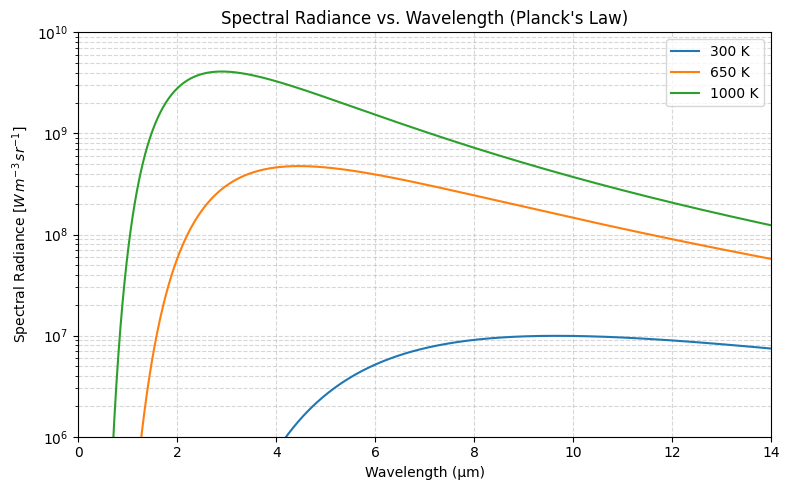

In [193]:
# Wavelengths from 0.1 to 14 micrometers, avoid zero to prevent division by zero, in meters
wavelength_um = np.linspace(0.1, 14, 1000)
wavelength_m = wavelength_um * 1e-6

temperatures = [300, 650, 1000]
labels = ["300 K", "650 K", "1000 K"]

plt.figure(figsize=(8, 5))
for T, label in zip(temperatures, labels):
    radiance = planck_lambda(wavelength_m, T)
    plt.plot(wavelength_um, radiance, label=label)

plt.xlabel("Wavelength (μm)")
plt.ylabel(r"Spectral Radiance $[W\,m^{-3}\,sr^{-1}]$")
plt.title("Spectral Radiance vs. Wavelength (Planck's Law)")
plt.yscale('log')
plt.ylim(1e6, 1e10)
plt.legend()
plt.xlim(0, 14)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.show()

## Atmospheric Transmission / MODTRAN simulation
Using MODTRAN, the atmospheric transmission for a range of wavelengths can be determined

In [194]:
import pandas as pd

def get_modtran_data(file_path):
    """
    Load MODTRAN simulation data from a CSV file.
    
    Parameters:
    - file_path: Path to the CSV file containing MODTRAN data.
    
    Returns:
    - DataFrame with columns 'Wavelength' and 'Transmission'.
    """
    df = pd.read_csv(file_path, header=4)
    df.set_index('Freq', inplace=True)
    df = df.iloc[1:-1]
    df.index = 1e-2 / df.index.astype(float)
    df.index.name = 'Wavelength [m]'
    df.columns = df.columns.str.strip()
    df['combin'] = pd.to_numeric(df['combin'], errors='coerce')
    tau = df['combin'].values
    wavelength = df.index.values
    sort_idx = np.argsort(wavelength)
    wavelength = wavelength[sort_idx]
    tau = tau[sort_idx]
    return wavelength, tau, df

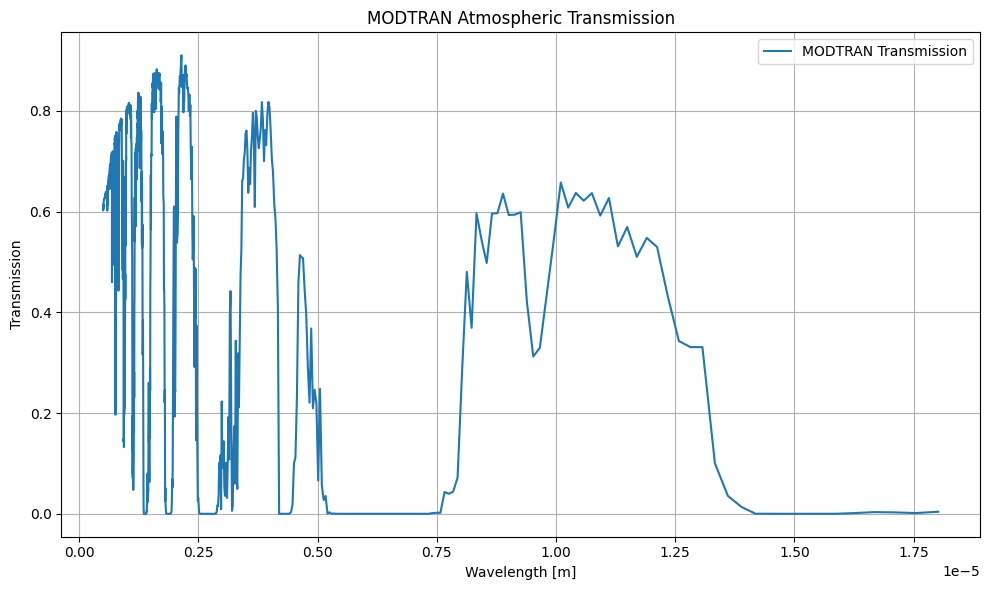

In [195]:
wavelength, transmittance, _ =  get_modtran_data('./AngstromLaw2.csv')
wavelength = wavelength
plt.figure(figsize=(10, 6))
plt.plot(wavelength, transmittance, label='MODTRAN Transmission', color='tab:blue')
plt.xlabel('Wavelength [m]')
plt.ylabel('Transmission')
plt.title('MODTRAN Atmospheric Transmission')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Imager Specification
**Teledyne FLIR Boson+**
| Param                | Value         | Description                       |
|----------------------|------------------------|------------------------------------|
| **Wavelength-Range** | 8–14 µm                | LWIR-Spectral-Range               |
| **NETD**             | 40 mK, 50 mK, 60 mK     | Detector-Noise, depends on the imager variant|
| **HFOV**              | 34° | Field of View; Only for Testing         |
| **Pixel Pitch**      | 12 µm                   | Detector-Pixel-Size                |
| **Optical Transmission** | τ<sub>opt</sub> = 0.9 | Transmission of the Optic             |
| **Pixel Count** | 320x256 / 640x512 | Number of Pixels in the matrix             |
| **IFOV (mrad)** | 1.9047619047619 | Instantaneous FoV; What a single pixel sees|

**Mission Environment (Different Optic)**

When two numbers - Pixel count: left for 320x256 / right for 640x512 
| Param                | Value         | Description                       |
|----------------------|------------------------|------------------------------------|
| **HFOV**      | 6° / 12° | Field of View; depends on the used Optic and Pixel Count|
| **GSD**       | 197m | Ground Sampling Distance for a single Pixel|
| **Swath width**       | 62889m / 126125m | How much the whole imager sees on the ground|

**Simulation Parameters**
| Param                | Value         | Description                       |
|----------------------|------------------------|------------------------------------|
| **Distance**       | 600km | Common orbit for CubeSats|
| **GSD**       | 197m | Ground Sampling Distance; Ground resolution|
| **Normal soil temperature**       | 300K | standard Industry estimation |
| **Fire temperature**       | 1000K | standard Industry estimation |
| **Optical Transmission**       | 0.9 (0.5) | estimation (for a 5 lens design) |
| **Detector-Efficiency**       | 0.8 | estimation |
| **Aperture-Diameter**       | 0.06m | estimation |


In [196]:
D = 0.06    # Aperture Diameter
d = 600e3   # Orbit radius
theta_ap = 0.5 * D / d  # Aperture half-angle

tau_op = 0.5    # optical Transmission
alpha_det = 0.8 # detector efficiency

T_fire = 1000   # Temperature Fire
T_ground = 300  # Temperature Soil

gsd = 200       # Ground Sampling Distance
area = gsd**2   # Ground Area

condition = (wavelength >= 8e-6) & (wavelength <= 14e-6)    # Condition for filtering MODTRAN data
band_edges = wavelength[condition]  # Band edges
tau_atm = transmittance[condition]  # Band transmittance

netd_values = [0.04, 0.05, 0.06]    # NETD Values

Fno = 2  # F-number

## FURTHER SIMULATION PARAMETERS
temperatures = np.linspace(200, 500, 200);  # temperatures for simulation
delta_fire = np.linspace(0, 100, 200);      # Fire Ratios for simulation

## Power Formula
Assuming Lambertian Emission and the detector being at nadir:
$$
P_\mathrm{ow} = A_\mathrm{surface}  \cdot \left[ \sum_{n=1}^{N} \tau_n \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]\cdot \pi \sin^2(\theta_\mathrm{ap})
$$

$$
P_\mathrm{tw} = A_\mathrm{surface}  \cdot \left[ \sum_{n=1}^{N} \tau_n^2 \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]\cdot \pi \sin^2(\theta_\mathrm{ap})
$$

In [197]:
def integrate_band(T, lmbd_min, lmbd_max, n_samples=200):
    """
    Integrates Planck radiance over [lmbd_min, lmbd_max].
    Returns [W / (m^2 sr)].
    """
    wavelengths = np.linspace(lmbd_min, lmbd_max, n_samples)
    spectral = planck_lambda(wavelengths, T)
    return np.trapezoid(spectral, wavelengths)

def generic_band_power(band_edges: np.array, tau_band, area: float, spectral_func, theta_ap, single_transmission, 
                       spectral_args, 
                       factor, n_samples=400):
    """
    Generic band-integrated power calculator.

    band_edges: array of wavelength edges [m]
    tau_band: array of transmission per band (len = len(band_edges)-1)
    area: pixel area [m^2]
    spectral_func: function(lmbd, *spectral_args) -> spectral radiance [W/(m^3 sr)]
    spectral_args: tuple of extra arguments for spectral_func (e.g. temperature)
    factor: constant prefactor (e.g. pi * emissivity, pi * albedo * geom, etc.)
    n_samples: integration samples per band

    Returns: array of powers per band [W], total power [W]
    """
    powers = []
    for i in range(len(band_edges)-1):
        l0, l1 = band_edges[i], band_edges[i+1]
        wavelengths = np.linspace(l0, l1, n_samples)
        spectral = spectral_func(wavelengths, *spectral_args)
        I_band = np.trapezoid(spectral, wavelengths)  # [W/(m^2 sr)]
        # debug: print(f"Band {i}: Wavelengths {l0:.2e} to {l1:.2e}, Integrated Radiance: {I_band:.2e} W/(m^2 sr)")
        if single_transmission:
            # If single transmission value is provided, apply it directly
            I_band_atm = I_band * tau_band[i]
        else:
            I_band_atm = I_band * tau_band[i]**2
        # debug: print(f"Band {i}: Transmission: {tau_band[i]:.2e}, Adjusted Radiance: {I_band_atm:.2e} W/(m^2 sr)")
        solid_angle_factor = pi * (np.sin(theta_ap))**2
        P_band = factor * area * I_band_atm * solid_angle_factor
        powers.append(P_band)
    powers = np.array(powers)
    return powers, powers.sum()

## Band Power for Ground Emission

**Ground Emission:**
$$
P_\mathrm{surface} = A_\mathrm{px} \cdot \tau_\mathrm{opt} \cdot \alpha_\mathrm{det} \cdot \epsilon_{ground} \cdot \left[ \sum_{n=1}^{N} \tau_n \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]\cdot \pi \sin^2(\theta_\mathrm{ap}) 
$$

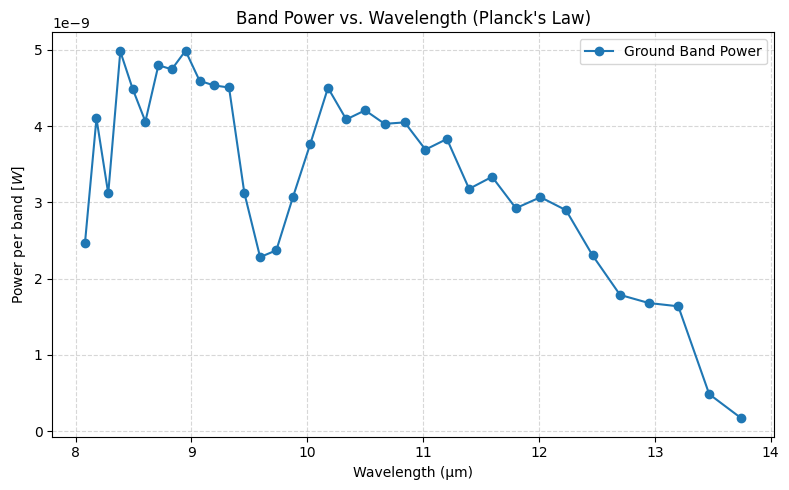

In [198]:
ground_powers, _ = generic_band_power(
        band_edges, tau_atm, area, theta_ap=theta_ap,
        spectral_func=planck_lambda, spectral_args=(T,),
        factor=tau_op * alpha_det,
        single_transmission=True
    )
# band_edges has length N+1 while ground_powers has length N -> use band centers for x
band_centers_um = 0.5 * (band_edges[:-1] + band_edges[1:]) * 1e6

plt.figure(figsize=(8, 5))
plt.plot(band_centers_um, ground_powers, marker='o', label="Ground Band Power")

plt.xlabel("Wavelength (μm)")
plt.ylabel(r"Power per band $[W]$")
plt.title("Band Power vs. Wavelength (Planck's Law)")
#plt.yscale('log')

plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

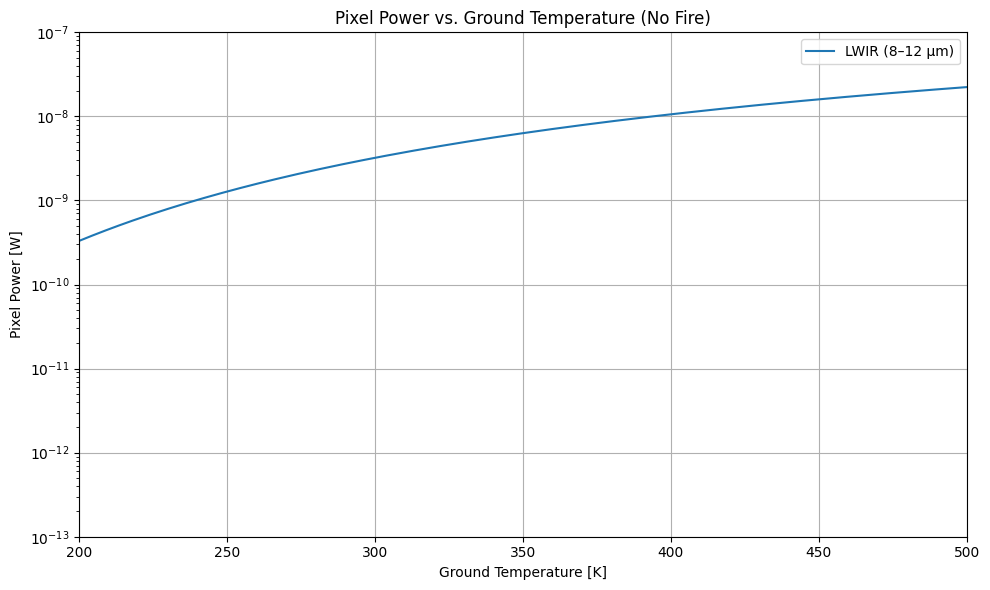

In [199]:
total_powers = []
for T in temperatures:
    _, total_power = generic_band_power(
        band_edges, tau_atm, area, theta_ap=theta_ap,
        spectral_func=planck_lambda, spectral_args=(T,),
        factor=tau_op * alpha_det,
        single_transmission=True
    )
    total_powers.append(total_power);

fig1 = plt.figure(figsize=(10, 6))

plt.plot(temperatures, total_powers, label='LWIR (8–12 µm)')
plt.yscale('log')  # Logarithmic scale for better visibility
plt.xlim(200, 500)
plt.ylim(1e-13, 1e-7)  # Adjust y-axis limits for better visibility
plt.xlabel('Ground Temperature [K]')
plt.ylabel('Pixel Power [W]')
plt.title('Pixel Power vs. Ground Temperature (No Fire)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## NETD / NEP

NETD and NEP are linked via the chain **scene -> radiance -> optic -> detector**

$$
\text{NEP} \;\approx\; 
\underbrace{\frac{\mathrm d P_\text{det}}{\mathrm d T}}_{\text{[W/K] at the operating point }T_0}
\cdot \text{NETD}
$$

$$
\frac{\mathrm d P_\text{px}}{\mathrm d T} \;=\;
A_\text{det}\;\tau_\text{opt}\;\pi\;\sin(\theta_{ap})\;\frac{\pi}{4\,F\#^2}
\int_{\lambda_1}^{\lambda_2} 
\underbrace{\frac{\partial S(\lambda,T)}{\partial T}}_{\text{Planck-derivate}}
\;\underbrace{\tau_\text{atm}(\lambda)}_{\text{one-way}}
\;\mathrm d\lambda
$$

- $S(\lambda,T)$: Planck-Radiance  
- $\tau_\text{atm}(\lambda)$: atmospheric transmission  
- $\tau_\text{opt}$: optical transmission
- $F\#$: f-number  
- $\theta_{ap}$: Aperture half-angle
- $A_\text{px}$: pixel area on the ground  

The derivative of Planck's law $S(\lambda, T)$ with respect to the temperature $T$ yields:

$$
\frac{\partial S(\lambda, T)}{\partial T} =
\frac{2 h c^2}{\lambda^5} \cdot
\frac{\exp\left(\frac{h c}{\lambda k T}\right) \cdot \frac{h c}{\lambda k T^2}}
{\left[\exp\left(\frac{h c}{\lambda k T}\right) - 1\right]^2}
$$

In [200]:
def dplanck_dT(lmbd, T):
    # ∂B/∂T analytisch (ableiten der Exponentialform)
    x = (h*c)/(lmbd*k*T)
    expx = np.exp(x)
    # d/dT [ 1/(e^x -1) ] = -(e^x * dx/dT)/(e^x -1)^2
    dx_dT = -(h*c)/(lmbd*k*T**2)
    pref = 2*h*c**2 / lmbd**5
    return pref * ( -(expx * dx_dT) / (expx - 1)**2 )

def dPdet_dT(
    T0,                       # Arbeitspunkt [K]
    lambdas,                  # feine λ-Achse [m]
    tau_atm_lambda,           # τ_atm(λ) (gleiche Länge wie lambdas)
    area,                     # Area on the surface
    F_number,                 # F#
    tau_opt,               # optische Transmission (skalar oder spektral passend zu lambdas)
    theta_ap  # Aperturwinkel [rad] 
):
    # Verwende generic_band_power für die Ableitung
    # Integration über das Band
    # Da lambdas und tau_atm_lambda Arrays sind, nehmen wir sie als "Band"
    # Der Faktor ist pi/(4*F_number**2)
    # tau_opt kann skalar oder array sein, wird als Faktor multipliziert
    factor = pi / (4 * F_number**2) * tau_opt
    # generic_band_power erwartet Bandkanten und Transmission pro Band
    # Wir machen ein "Band" von lambdas[0] bis lambdas[-1]

    # Berechne die bandintegrierte Ableitung
    powers, total = generic_band_power(band_edges=lambdas,
                                       tau_band=tau_atm_lambda, 
                                       area=area,
                                       theta_ap=theta_ap,  # Beispiel-Aperturwinkel
                                       spectral_func=dplanck_dT, spectral_args=(T0,),
                                       factor=factor, single_transmission=True
    )
    return powers, total  # [W/K]

def netd_to_nep(
    NETD,                     # [K]
    T0, lambdas, tau_atm_lambda,
    area, F_number, tau_opt, theta_ap : float # Aperturwinkel [rad]
):
    _, dP_dT = dPdet_dT(T0, lambdas, tau_atm_lambda, area, F_number, tau_opt,theta_ap)
    NEP = dP_dT * NETD        # [W] (für die angegebene Integrationszeit)
    return NEP, dP_dT

In [201]:
# Berechne NEP für jeden NETD-Wert
nep_results = {}
for netd in netd_values:
    nep = []
    for T in temperatures:
        nep_single, dP_dT_val = netd_to_nep(
            NETD=netd,
            T0=T,
            lambdas=band_edges, # hier nur die Wellenlänge des Sensors
            tau_atm_lambda=tau_atm,
            area=area,
            F_number=Fno,
            tau_opt=tau_op,
            theta_ap=theta_ap  # Beispiel-Aperturwinkel
        )
        nep.append(nep_single)
    nep_results[netd] = nep
# Ausgabe
for netd, nep in nep_results.items():
    print(f"NETD = {netd:.3f} K → NEP (mean) = {np.mean(nep):.3e} W")

NETD = 0.040 K → NEP (mean) = 7.196e-13 W
NETD = 0.050 K → NEP (mean) = 8.995e-13 W
NETD = 0.060 K → NEP (mean) = 1.079e-12 W


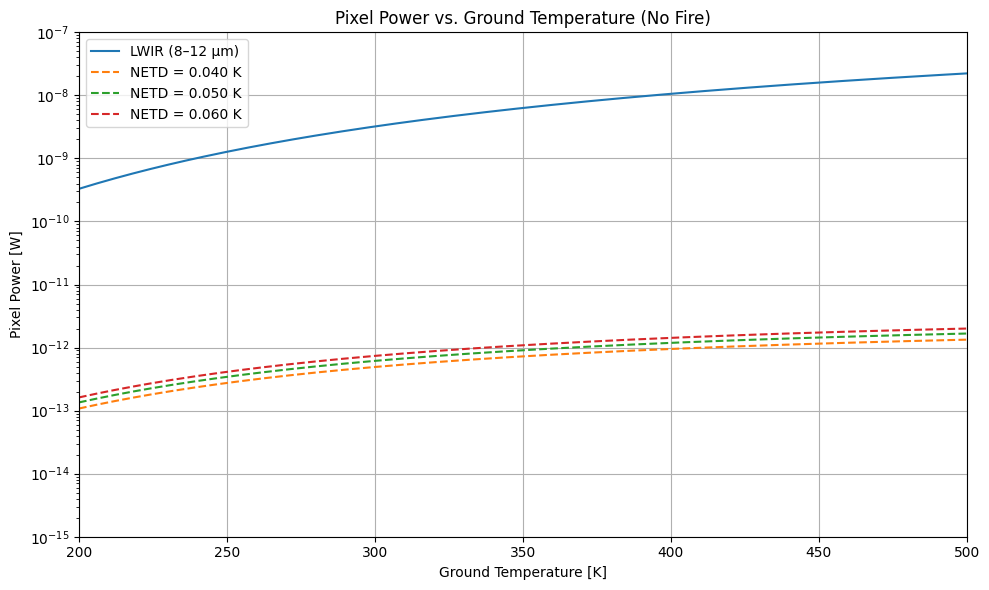

In [202]:
# Plot der NEP-Ergebnisse
plt.figure(figsize=(10, 6))
plt.plot(temperatures, total_powers, label='LWIR (8–12 µm)')
for netd, nep in nep_results.items():
    plt.plot(temperatures, nep, label=f'NETD = {netd:.3f} K', linestyle='--')
plt.yscale('log')  # Logarithmic scale for better visibility
plt.xlim(200, 500)
plt.ylim(1e-15, 1e-7)  # Adjust y-axis limits for better visibility
plt.xlabel('Ground Temperature [K]')
plt.ylabel('Pixel Power [W]')
plt.title('Pixel Power vs. Ground Temperature (No Fire)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Mixed Pixels:
$$P_{mix,Band} = (1 - \delta_{fire}) \cdot P_{ground,Band} + \delta_{fire} \cdot P_{fire,Band} $$

In [203]:
def mixed_pixel_power_ground_fire(T_ground, T_fire, delta_fire, band_edges, tau_band, area, tau_opt, alpha_det, theta_ap):
    """
    Berechnet die Gesamtleistung eines Pixels mit Boden/Feuer-Mischung, Albedo und Glint.
    delta_fire: Anteil Feuer im Pixel (z.B. 0.1 für 10%)
    area: Pixel-Fläche [m^2]
    """

    factor = tau_opt * alpha_det
    # Boden-Emission
    P_ground_band, _ = generic_band_power(band_edges, tau_band, area, spectral_func=planck_lambda, theta_ap=theta_ap, 
                                                       single_transmission=True, spectral_args=(T_ground,), factor=factor)
    # Feuer-Emission
    P_fire_band, _ = generic_band_power(band_edges, tau_band, area, spectral_func=planck_lambda, theta_ap=theta_ap, 
                                                       single_transmission=True, spectral_args=(T_fire,), factor=factor)

        # Gemischte Pixel-Leistung
    P_mix_band = (1 - delta_fire) * P_ground_band + delta_fire * P_fire_band

    return P_mix_band, P_mix_band.sum()

ValueError: x and y must have same first dimension, but have shapes (200,) and (1,)

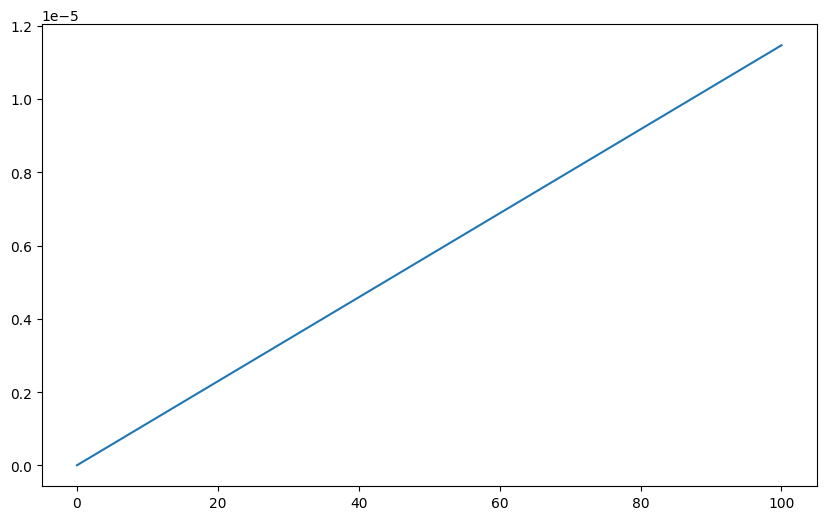

In [ ]:
mix_powers = []
for delta_cur in delta_fire:
    _ , cur_power = mixed_pixel_power_ground_fire(T_ground, T_fire, delta_cur, band_edges, tau_atm, area, tau_op, alpha_det, theta_ap)
    mix_powers.append(cur_power)

nep_fire, _ = netd_to_nep(netd_values[2], T_fire, band_edges, tau_atm, area, Fno, tau_op, theta_ap)
nep_fire_array = [nep_fire] * len(delta_fire)

plt.figure(figsize=(10,6))
plt.plot(delta_fire, mix_powers)
plt.plot(delta_fire, nep_fire_array)
plt.yscale("log")
plt.xlim(0, 100)
plt.xlabel('Delta Fire')
plt.ylabel('Power')
plt.title('Bandweise Pixel-Leistung (Boden/Feuer-Mix, Albedo, Glint)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Todos:
    - reading of modtran data gives band centers, but are used as band edges
    - Single transmission bei netd berechnung